# Lab: Analisis de paquetes de red
### Sebastian Juarez 21471

## Testeo de la herramienta

In [5]:
from pathlib import Path

import pandas as pd
from scapy.all import IP, IPv6, TCP, UDP, PacketList, rdpcap, sniff, wrpcap

In [6]:
CAPTURE_COUNT = 10
OUTPUT_PCAP = Path("captura_10_paquetes.pcap")
FALLBACK_PCAP = Path("analisis_paquetes.pcap")

def capturar_o_cargar_paquetes(count=10):
    try:
        paquetes = sniff(count=count, timeout=30)
        if len(paquetes) == count:
            wrpcap(str(OUTPUT_PCAP), paquetes)
            print(f"Se capturaron {len(paquetes)} paquetes y se guardaron en {OUTPUT_PCAP}.")
            return paquetes, OUTPUT_PCAP
        print(f"Solo se capturaron {len(paquetes)} paquetes en vivo.")
    except Exception as exc:
        print(f"No se pudo capturar en vivo: {exc}")

    if FALLBACK_PCAP.exists():
        paquetes = rdpcap(str(FALLBACK_PCAP))[:count]
        print(f"Usando {len(paquetes)} paquetes desde {FALLBACK_PCAP} como respaldo.")
        return paquetes, FALLBACK_PCAP

    raise FileNotFoundError("No fue posible capturar paquetes ni existe un pcap de respaldo.")

paquetes, archivo_pcap = capturar_o_cargar_paquetes(CAPTURE_COUNT)

No se pudo capturar en vivo: Permission denied: could not open /dev/bpf0. Make sure to be running Scapy as root ! (sudo)
Usando 10 paquetes desde analisis_paquetes.pcap como respaldo.


In [7]:
print("Archivo usado:", archivo_pcap)
print("Tipo de dato:", type(paquetes))
print("Longitud:", len(paquetes))

print("\nResumen del contenido del pcap:")
paquetes.summary()

print("\nDetalle de cada paquete:")
for indice, paquete in enumerate(paquetes, start=1):
    print(f"\nPaquete {indice}")
    print(paquete.show(dump=True))

Archivo usado: analisis_paquetes.pcap
Tipo de dato: <class 'scapy.plist.PacketList'>
Longitud: 10

Resumen del contenido del pcap:
Ether / IP / UDP / DNS Qry b'google.com.' / Raw
Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807::200e
Ether / IP / UDP / DNS Qry b'google.com.' / Raw
Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807::200e
Ether / IP / UDP / DNS Qry b'google.com.' / Raw
Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807::200e
Ether / IP / UDP / DNS Qry b'google.com.' / Raw
Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807::200e
Ether / IP / UDP / DNS Qry b'google.com.' / Raw
Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807::200e

Detalle de cada paquete:

Paquete 1
###[ Ethernet ]###
  dst       = 80:37:73:96:9b:db
  src       = 88:e9:fe:6a:92:52
  type      = IPv4
###[ IP ]###
     version   = 4
     ihl       = 5
     tos       = 0x0
     len       = 961
     id        = 1
     flags     = 
     frag      = 0
     ttl       = 64
     proto     = udp
     chksum    = 0x52e6
     src       =

In [8]:
def extraer_campos(paquete):
    src_address = None
    dst_address = None
    src_port = None
    dst_port = None

    if paquete.haslayer(IP):
        src_address = paquete[IP].src
        dst_address = paquete[IP].dst
    elif paquete.haslayer(IPv6):
        src_address = paquete[IPv6].src
        dst_address = paquete[IPv6].dst

    if paquete.haslayer(TCP):
        src_port = paquete[TCP].sport
        dst_port = paquete[TCP].dport
    elif paquete.haslayer(UDP):
        src_port = paquete[UDP].sport
        dst_port = paquete[UDP].dport

    return {
        "Src Address": src_address,
        "Dst Address": dst_address,
        "Src Port": src_port,
        "Dst Port": dst_port,
    }

filas = [extraer_campos(paquete) for paquete in paquetes]
df_conexiones = pd.DataFrame(filas)
df_conexiones[["Src Address", "Dst Address", "Src Port", "Dst Port"]]

,Src Address,Dst Address,Src Port,Dst Port
0,10.1.10.53,84.54.22.33,53,53
1,84.54.22.33,10.1.10.53,53,53
2,10.1.10.53,84.54.22.33,53,53
3,84.54.22.33,10.1.10.53,53,53
4,10.1.10.53,84.54.22.33,53,53
5,84.54.22.33,10.1.10.53,53,53
6,10.1.10.53,84.54.22.33,53,53
7,84.54.22.33,10.1.10.53,53,53
8,10.1.10.53,84.54.22.33,53,53
9,84.54.22.33,10.1.10.53,53,53


# Estadisticas y detección con z-score

In [9]:
from scapy.all import DNS

pcap_path = Path("analisis_paquetes.pcap")
paquetes_pcap = rdpcap(str(pcap_path))

print("Tipo de dato:", type(paquetes_pcap))
print("Cantidad de paquetes:", len(paquetes_pcap))

Tipo de dato: <class 'scapy.plist.PacketList'>
Cantidad de paquetes: 62


In [10]:
def obtener_payload_len(paquete):
    if paquete.haslayer(TCP):
        return len(bytes(paquete[TCP].payload))
    if paquete.haslayer(UDP):
        return len(bytes(paquete[UDP].payload))
    return len(bytes(paquete.payload))

def obtener_protocolo(paquete):
    if paquete.haslayer(DNS):
        return "DNS"
    if paquete.haslayer(TCP):
        return "TCP"
    if paquete.haslayer(UDP):
        return "UDP"
    return paquete.lastlayer().name

def paquete_a_fila(numero, paquete):
    fila = extraer_campos(paquete)
    fila.update({
        "No": numero,
        "Protocol": obtener_protocolo(paquete),
        "packet_len": len(paquete),
        "payload_len": obtener_payload_len(paquete),
        "summary": paquete.summary(),
    })
    return fila

df_pcap = pd.DataFrame(
    paquete_a_fila(numero, paquete)
    for numero, paquete in enumerate(paquetes_pcap, start=1)
)

df_pcap.head()

,Src Address,Dst Address,Src Port,Dst Port,No,Protocol,packet_len,payload_len,summary
0,10.1.10.53,84.54.22.33,53,53,1,DNS,975,933,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
1,84.54.22.33,10.1.10.53,53,53,2,DNS,98,56,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...
2,10.1.10.53,84.54.22.33,53,53,3,DNS,989,947,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
3,84.54.22.33,10.1.10.53,53,53,4,DNS,98,56,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...
4,10.1.10.53,84.54.22.33,53,53,5,DNS,1026,984,Ether / IP / UDP / DNS Qry b'google.com.' / Raw


## Estadisticas basicas

In [11]:
ip_origen_mas_frecuente = df_pcap["Src Address"].value_counts().idxmax()
ip_destino_mas_frecuente = df_pcap["Dst Address"].value_counts().idxmax()

print("IP origen mas frecuente:", ip_origen_mas_frecuente)
display(df_pcap["Src Address"].value_counts().rename_axis("Src Address").reset_index(name="Frecuencia"))

print("IP destino mas frecuente:", ip_destino_mas_frecuente)
display(df_pcap["Dst Address"].value_counts().rename_axis("Dst Address").reset_index(name="Frecuencia"))

IP origen mas frecuente: 10.1.10.53


,Src Address,Frecuencia
0,10.1.10.53,31
1,84.54.22.33,29
2,75.75.75.75,2


IP destino mas frecuente: 10.1.10.53


,Dst Address,Frecuencia
0,10.1.10.53,31
1,84.54.22.33,29
2,75.75.75.75,2


In [12]:
ips_destino_de_origen_frecuente = (
    df_pcap.loc[df_pcap["Src Address"] == ip_origen_mas_frecuente, "Dst Address"]
    .value_counts()
    .rename_axis("IP destino")
    .reset_index(name="Frecuencia")
)

puertos_destino_de_origen_frecuente = (
    df_pcap.loc[df_pcap["Src Address"] == ip_origen_mas_frecuente, "Dst Port"]
    .dropna()
    .astype(int)
    .value_counts()
    .rename_axis("Puerto destino")
    .reset_index(name="Frecuencia")
)

puertos_origen_de_destino_frecuente = (
    df_pcap.loc[df_pcap["Dst Address"] == ip_destino_mas_frecuente, "Src Port"]
    .dropna()
    .astype(int)
    .value_counts()
    .rename_axis("Puerto origen")
    .reset_index(name="Frecuencia")
)

print(f"IPs a las que se comunica {ip_origen_mas_frecuente}:")
display(ips_destino_de_origen_frecuente)

print(f"Puertos destino a los que se comunica {ip_origen_mas_frecuente}:")
display(puertos_destino_de_origen_frecuente)

print(f"Puertos origen que se comunican hacia {ip_destino_mas_frecuente}:")
display(puertos_origen_de_destino_frecuente)

IPs a las que se comunica 10.1.10.53:


,IP destino,Frecuencia
0,84.54.22.33,29
1,75.75.75.75,2


Puertos destino a los que se comunica 10.1.10.53:


,Puerto destino,Frecuencia
0,53,31


Puertos origen que se comunican hacia 10.1.10.53:


,Puerto origen,Frecuencia
0,53,31


In [13]:
def proposito_puerto(puerto):
    propositos = {
        20: "FTP data",
        21: "FTP control",
        22: "SSH",
        25: "SMTP",
        53: "DNS: resolucion de nombres de dominio",
        67: "DHCP servidor",
        68: "DHCP cliente",
        80: "HTTP",
        110: "POP3",
        123: "NTP",
        143: "IMAP",
        443: "HTTPS",
    }
    return propositos.get(int(puerto), "Puerto no identificado en la tabla basica")

puertos_mas_frecuentes = pd.concat([
    puertos_destino_de_origen_frecuente.rename(columns={"Puerto destino": "Puerto"}).assign(Contexto="Destino desde IP origen mas frecuente"),
    puertos_origen_de_destino_frecuente.rename(columns={"Puerto origen": "Puerto"}).assign(Contexto="Origen hacia IP destino mas frecuente"),
], ignore_index=True)

puertos_mas_frecuentes["Proposito"] = puertos_mas_frecuentes["Puerto"].apply(proposito_puerto)
puertos_mas_frecuentes[["Contexto", "Puerto", "Frecuencia", "Proposito"]]

,Contexto,Puerto,Frecuencia,Proposito
0,Destino desde IP origen mas frecuente,53,31,DNS: resolucion de nombres de dominio
1,Origen hacia IP destino mas frecuente,53,31,DNS: resolucion de nombres de dominio


En este archivo aparece principalmente el puerto 53, que corresponde a DNS. Esto nos dice que el trafico que estamos viendo esta relacionado con consultas o respuestas de nombres de dominio.

## Z-Score sobre el tamano del payload

Primero se calcula el Z-score usando la media y desviacion estandar del propio `pcap`.

In [14]:
media_payload = df_pcap["payload_len"].mean()
std_payload = df_pcap["payload_len"].std(ddof=0)

df_pcap["z_payload"] = (df_pcap["payload_len"] - media_payload) / std_payload

anomalias_z2 = df_pcap[df_pcap["z_payload"].abs() > 2]
anomalias_z3 = df_pcap[df_pcap["z_payload"].abs() > 3]

print(f"Media payload_len: {media_payload:.2f}")
print(f"Desviacion estandar payload_len: {std_payload:.2f}")
print("Paquetes con |Z| > 2:", len(anomalias_z2))
print("Paquetes con |Z| > 3:", len(anomalias_z3))

display(anomalias_z2[["No", "Src Address", "Dst Address", "Src Port", "Dst Port", "Protocol", "payload_len", "z_payload", "summary"]])

Media payload_len: 481.34
Desviacion estandar payload_len: 456.54
Paquetes con |Z| > 2: 0
Paquetes con |Z| > 3: 0


,No,Src Address,Dst Address,Src Port,Dst Port,Protocol,payload_len,z_payload,summary


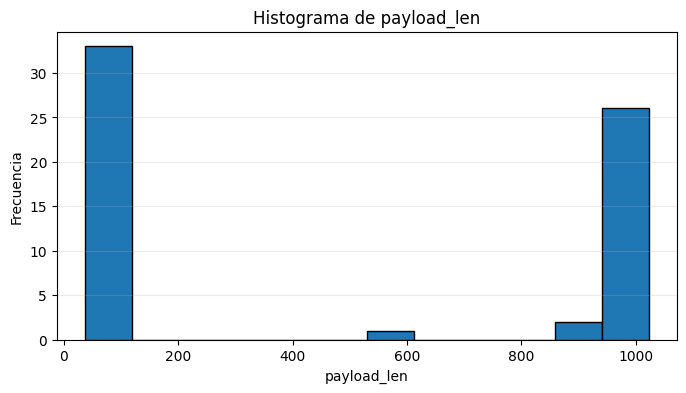

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(df_pcap["payload_len"], bins=12, edgecolor="black")
plt.title("Histograma de payload_len")
plt.xlabel("payload_len")
plt.ylabel("Frecuencia")
plt.grid(axis="y", alpha=0.25)
plt.show()

La distribucion de payload_len no parece normal ya que hay muchos paquetes pequeños y otros paquetes mucho mas grandes. Por esto, el Z-score calculado con la media y desviacion del mismo pcap puede no detectar datos extraños porque los paquetes grandes elevan mucho la media y la desviacion estandar. Ya que se infla la desviacion, los valores grandes dejan de verse tan grandes en terminos de Z-score.

## Z-Score usando conocimiento de dominio DNS

In [16]:
media_dns = 50
std_dns = 15

df_pcap["z_payload_dns_ref"] = (df_pcap["payload_len"] - media_dns) / std_dns

anomalias_dns_z2 = df_pcap[df_pcap["z_payload_dns_ref"].abs() > 2]
anomalias_dns_z3 = df_pcap[df_pcap["z_payload_dns_ref"].abs() > 3]

print("Paquetes detectados con referencia DNS y |Z| > 2:", len(anomalias_dns_z2))
print("Paquetes detectados con referencia DNS y |Z| > 3:", len(anomalias_dns_z3))

display(anomalias_dns_z2[["No", "Src Address", "Dst Address", "Src Port", "Dst Port", "Protocol", "payload_len", "z_payload_dns_ref", "summary"]])

Paquetes detectados con referencia DNS y |Z| > 2: 30
Paquetes detectados con referencia DNS y |Z| > 3: 29


,No,Src Address,Dst Address,Src Port,Dst Port,Protocol,payload_len,z_payload_dns_ref,summary
0,1,10.1.10.53,84.54.22.33,53,53,DNS,933,58.866667,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
2,3,10.1.10.53,84.54.22.33,53,53,DNS,947,59.800000,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
4,5,10.1.10.53,84.54.22.33,53,53,DNS,984,62.266667,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
6,7,10.1.10.53,84.54.22.33,53,53,DNS,970,61.333333,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
8,9,10.1.10.53,84.54.22.33,53,53,DNS,975,61.666667,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
10,11,10.1.10.53,84.54.22.33,53,53,DNS,1017,64.466667,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
12,13,10.1.10.53,84.54.22.33,53,53,DNS,980,62.000000,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
14,15,10.1.10.53,84.54.22.33,53,53,DNS,951,60.066667,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
16,17,10.1.10.53,84.54.22.33,53,53,DNS,931,58.733333,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
18,19,10.1.10.53,84.54.22.33,53,53,DNS,964,60.933333,Ether / IP / UDP / DNS Qry b'google.com.' / Raw


Viendo el DNS, los paquetes con payload mucho mayor al esperado los tomamos como anomalos. Esto nos dice que usar una tecnica estadistica bastante simple puede fallar si se aplica sin entender el protocolo y esto es por que la media y desviacion del conjunto que se vio pueden que tenga el mismo problema y que sean anomalos.

# Graficas de payload

In [17]:
def graficar_suma_payload(dataframe, columna, titulo, etiqueta_y):
    resumen = (
        dataframe.dropna(subset=[columna])
        .groupby(columna, as_index=False)["payload_len"]
        .sum()
        .sort_values("payload_len", ascending=True)
    )

    resumen[columna] = resumen[columna].astype(str)

    plt.figure(figsize=(8, 4))
    plt.barh(resumen[columna], resumen["payload_len"], color="#2f6f73")
    plt.title(titulo)
    plt.xlabel("Suma de payload_len")
    plt.ylabel(etiqueta_y)
    plt.grid(axis="x", alpha=0.25)
    plt.show()

    return resumen.rename(columns={columna: etiqueta_y, "payload_len": "Suma payload_len"})

## Payload enviado por IP origen

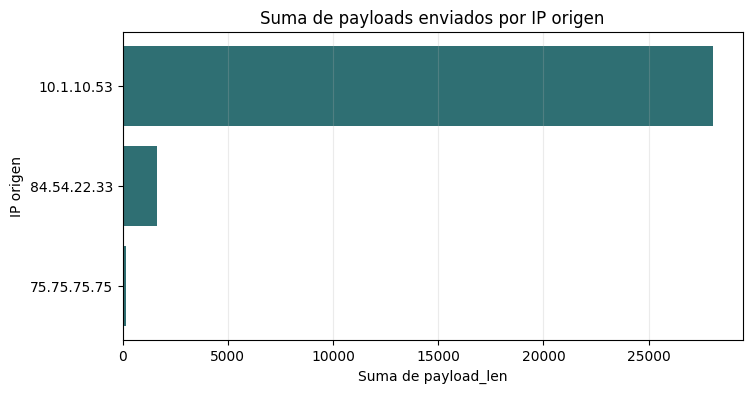

,IP origen,Suma payload_len
1,75.75.75.75,166
2,84.54.22.33,1624
0,10.1.10.53,28053


In [18]:
payload_por_ip_origen = graficar_suma_payload(
    df_pcap,
    "Src Address",
    "Suma de payloads enviados por IP origen",
    "IP origen",
)
payload_por_ip_origen

## Payload recibido por IP destino

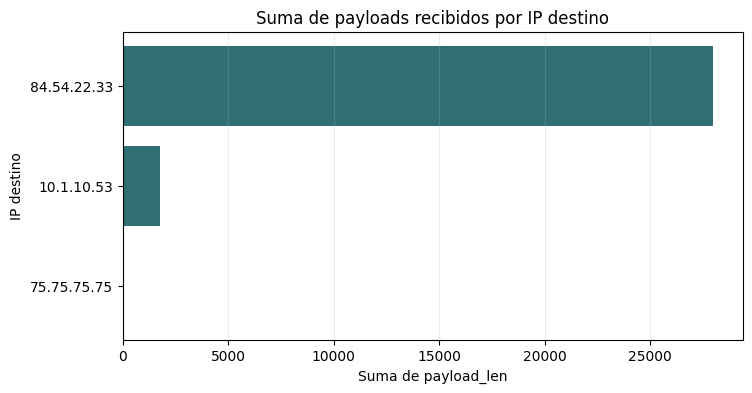

,IP destino,Suma payload_len
1,75.75.75.75,74
0,10.1.10.53,1790
2,84.54.22.33,27979


In [19]:
payload_por_ip_destino = graficar_suma_payload(
    df_pcap,
    "Dst Address",
    "Suma de payloads recibidos por IP destino",
    "IP destino",
)
payload_por_ip_destino

## Payload enviado por puerto origen

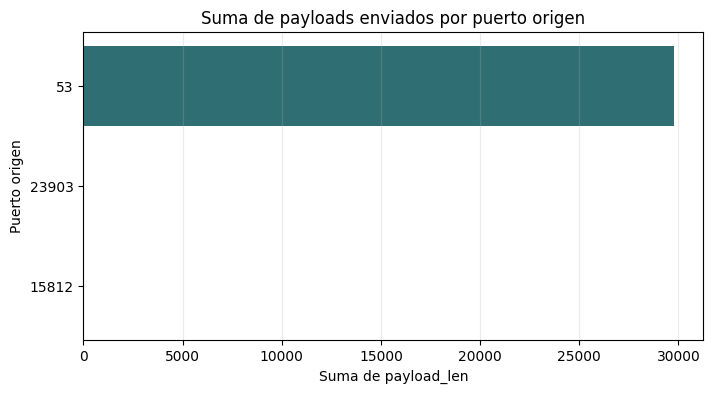

,Puerto origen,Suma payload_len
1,15812,37
2,23903,37
0,53,29769


In [20]:
payload_por_puerto_origen = graficar_suma_payload(
    df_pcap,
    "Src Port",
    "Suma de payloads enviados por puerto origen",
    "Puerto origen",
)
payload_por_puerto_origen

## Payload recibido por puerto destino

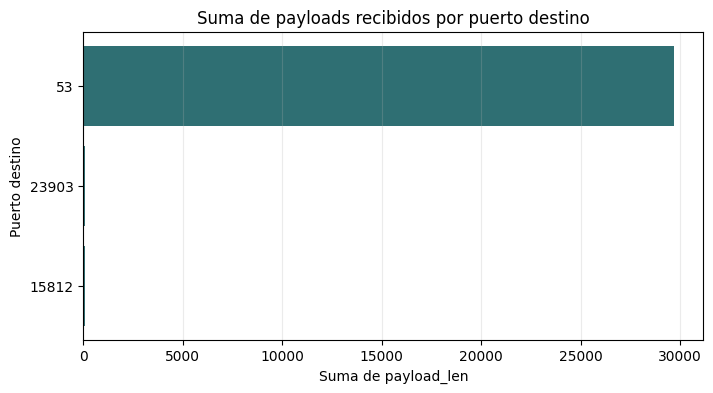

,Puerto destino,Suma payload_len
1,15812,77
2,23903,89
0,53,29677


In [21]:
payload_por_puerto_destino = graficar_suma_payload(
    df_pcap,
    "Dst Port",
    "Suma de payloads recibidos por puerto destino",
    "Puerto destino",
)
payload_por_puerto_destino

## Detección automática con Isolation Forest

Para este modelo vamos a usar las columnas numericas de payload_len y pkt_len. Vamos a calcular el valor de contamination como:

numero de paquetes anomalos detectados en el iniciso 4 c / numero total de paquetes

In [22]:
from sklearn.ensemble import IsolationForest

# El enunciado usa el nombre pkt_len; en el DataFrame ya teniamos packet_len.
df_pcap["pkt_len"] = df_pcap["packet_len"]

paquetes_anomalos_4c = len(anomalias_dns_z2)
paquetes_totales = len(df_pcap)
contamination = paquetes_anomalos_4c / paquetes_totales

print("Paquetes anomalos detectados en 4.c:", paquetes_anomalos_4c)
print("Paquetes totales:", paquetes_totales)
print(f"Contamination: {contamination:.4f}")

Paquetes anomalos detectados en 4.c: 30
Paquetes totales: 62
Contamination: 0.4839


In [23]:
features_iforest = df_pcap[["payload_len", "pkt_len"]]

modelo_iforest = IsolationForest(
    contamination=contamination,
    random_state=42,
)

df_pcap["iforest_pred"] = modelo_iforest.fit_predict(features_iforest)
df_pcap["iforest_score"] = modelo_iforest.decision_function(features_iforest)
df_pcap["iforest_anomalia"] = df_pcap["iforest_pred"] == -1

anomalias_iforest = (
    df_pcap[df_pcap["iforest_anomalia"]]
    .sort_values("iforest_score")
)

print("Paquetes marcados como anomalías por Isolation Forest:", len(anomalias_iforest))
display(anomalias_iforest[[
    "No", "Src Address", "Dst Address", "Src Port", "Dst Port",
    "payload_len", "pkt_len", "z_payload_dns_ref", "iforest_score", "summary"
]])

Paquetes marcados como anomalías por Isolation Forest: 30


,No,Src Address,Dst Address,Src Port,Dst Port,payload_len,pkt_len,z_payload_dns_ref,iforest_score,summary
60,61,10.1.10.53,84.54.22.33,53,53,560,602,34.000000,-0.387460,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
25,26,75.75.75.75,10.1.10.53,53,23903,89,131,2.600000,-0.306709,Ether / IP / UDP / DNS Ans b'clients.l.google....
24,25,75.75.75.75,10.1.10.53,53,15812,77,119,1.800000,-0.277504,Ether / IP / UDP / DNS Ans b'clients.l.google....
22,23,10.1.10.53,75.75.75.75,15812,53,37,79,-0.866667,-0.261438,Ether / IP / UDP / DNS Qry b'clients4.google.c...
23,24,10.1.10.53,75.75.75.75,23903,53,37,79,-0.866667,-0.261438,Ether / IP / UDP / DNS Qry b'clients4.google.c...
20,21,10.1.10.53,84.54.22.33,53,53,1023,1065,64.866667,-0.237722,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
16,17,10.1.10.53,84.54.22.33,53,53,931,973,58.733333,-0.176768,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
0,1,10.1.10.53,84.54.22.33,53,53,933,975,58.866667,-0.162694,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
10,11,10.1.10.53,84.54.22.33,53,53,1017,1059,64.466667,-0.153697,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
58,59,10.1.10.53,84.54.22.33,53,53,941,983,59.400000,-0.147661,Ether / IP / UDP / DNS Qry b'google.com.' / Raw


In [24]:
ids_zscore_4c = set(anomalias_dns_z2["No"])
ids_iforest = set(anomalias_iforest["No"])

coinciden = sorted(ids_zscore_4c & ids_iforest)
solo_zscore = sorted(ids_zscore_4c - ids_iforest)
solo_iforest = sorted(ids_iforest - ids_zscore_4c)

print("Anomalias que coinciden entre Z-score 4.c e Isolation Forest:", len(coinciden))
print("Solo Z-score 4.c:", solo_zscore)
print("Solo Isolation Forest:", solo_iforest)

comparacion_anomalias = pd.DataFrame({
    "Categoria": ["Coinciden", "Solo Z-score 4.c", "Solo Isolation Forest"],
    "Cantidad": [len(coinciden), len(solo_zscore), len(solo_iforest)],
})
comparacion_anomalias

Anomalias que coinciden entre Z-score 4.c e Isolation Forest: 27
Solo Z-score 4.c: [27, 45, 47]
Solo Isolation Forest: [23, 24, 25]


,Categoria,Cantidad
0,Coinciden,27
1,Solo Z-score 4.c,3
2,Solo Isolation Forest,3


Las anomalías que se vieron coinciden parcialmente con las del Z-score basado en conocimiento de dominio. Los dos métodos nos enseñaron principalmente paquetes DNS con payload_len alto, especialmente la conversación `10.1.10.53 -> 84.54.22.33` usando puerto `53`.

Sin embargo, estos no coinciden exactamente porque Isolation Forest no usa una regla fija que se base solo en el tamaño esperado de DNS. El modelo aprende la forma de los datos usando payload_len y pkt_len, por lo que también puede marcar paquetes pequeños y poco comunes dentro del conjunto, como algunos relacionados con `75.75.75.75`.

# Investigacion del payload (confirmacion manual)

In [25]:
def obtener_payload_bytes(paquete):
    if paquete.haslayer(TCP):
        return bytes(paquete[TCP].payload)
    if paquete.haslayer(UDP):
        return bytes(paquete[UDP].payload)
    return bytes(paquete.payload)

df_payload = df_pcap.copy()
df_payload["payload"] = [obtener_payload_bytes(paquete) for paquete in paquetes_pcap]

df_ip_origen_frecuente = df_payload[df_payload["Src Address"] == ip_origen_mas_frecuente].copy()

print("IP origen mas frecuente:", ip_origen_mas_frecuente)
print("Paquetes con esta IP como origen:", len(df_ip_origen_frecuente))
df_ip_origen_frecuente[["No", "Src Address", "Dst Address", "Src Port", "Dst Port", "payload_len", "summary"]].head()

IP origen mas frecuente: 10.1.10.53
Paquetes con esta IP como origen: 31


,No,Src Address,Dst Address,Src Port,Dst Port,payload_len,summary
0,1,10.1.10.53,84.54.22.33,53,53,933,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
2,3,10.1.10.53,84.54.22.33,53,53,947,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
4,5,10.1.10.53,84.54.22.33,53,53,984,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
6,7,10.1.10.53,84.54.22.33,53,53,970,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
8,9,10.1.10.53,84.54.22.33,53,53,975,Ether / IP / UDP / DNS Qry b'google.com.' / Raw


## Agrupacion por bytes de payload intercambiados

In [26]:
payload_agrupado_por_conversacion = (
    df_ip_origen_frecuente
    .groupby(["Src Address", "Dst Address"], as_index=False)["payload_len"]
    .sum()
    .rename(columns={"payload_len": "Bytes de payload"})
    .sort_values("Bytes de payload", ascending=False)
)

payload_agrupado_por_conversacion

,Src Address,Dst Address,Bytes de payload
1,10.1.10.53,84.54.22.33,27979
0,10.1.10.53,75.75.75.75,74


In [27]:
ip_sospechosa = payload_agrupado_por_conversacion.iloc[0]["Dst Address"]
bytes_intercambiados = payload_agrupado_por_conversacion.iloc[0]["Bytes de payload"]

print("IP que mas bytes intercambia con la IP mas frecuente:", ip_sospechosa)
print("Bytes de payload enviados hacia esa IP:", bytes_intercambiados)
print("Coincide con la IP sospechosa identificada por las tecnicas automaticas:", ip_sospechosa == "84.54.22.33")

IP que mas bytes intercambia con la IP mas frecuente: 84.54.22.33
Bytes de payload enviados hacia esa IP: 27979
Coincide con la IP sospechosa identificada por las tecnicas automaticas: True


La IP sospechosa es 84.54.22.33, que es la misma conversacion que aparecio como anomala en Z-score y en el Isolation Forest por tener payloads DNS mucho mas grandes de lo normal.

In [28]:
df_conversacion_sospechosa = df_payload[
    ((df_payload["Src Address"] == ip_origen_mas_frecuente) & (df_payload["Dst Address"] == ip_sospechosa)) |
    ((df_payload["Src Address"] == ip_sospechosa) & (df_payload["Dst Address"] == ip_origen_mas_frecuente))
].copy()

df_conversacion_sospechosa[[
    "No", "Src Address", "Dst Address", "Src Port", "Dst Port", "payload_len", "summary"
]].head(10)

,No,Src Address,Dst Address,Src Port,Dst Port,payload_len,summary
0,1,10.1.10.53,84.54.22.33,53,53,933,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
1,2,84.54.22.33,10.1.10.53,53,53,56,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...
2,3,10.1.10.53,84.54.22.33,53,53,947,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
3,4,84.54.22.33,10.1.10.53,53,53,56,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...
4,5,10.1.10.53,84.54.22.33,53,53,984,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
5,6,84.54.22.33,10.1.10.53,53,53,56,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...
6,7,10.1.10.53,84.54.22.33,53,53,970,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
7,8,84.54.22.33,10.1.10.53,53,53,56,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...
8,9,10.1.10.53,84.54.22.33,53,53,975,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
9,10,84.54.22.33,10.1.10.53,53,53,56,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...


In [29]:
payloads_sospechosos = df_conversacion_sospechosa["payload"].to_list()

print("Cantidad de payloads en la conversacion sospechosa:", len(payloads_sospechosos))
print("Longitud del primer payload:", len(payloads_sospechosos[0]))

Cantidad de payloads en la conversacion sospechosa: 58
Longitud del primer payload: 933


In [30]:
primer_payload = payloads_sospechosos[0]

print("Primer payload completo:")
print(primer_payload)

print("\nPrimeros 120 bytes en hexadecimal:")
print(primer_payload[:120].hex())

print("\nPrimeros 120 bytes en ASCII aproximado:")
print("".join(chr(byte) if 32 <= byte < 127 else "." for byte in primer_payload[:120]))

Primer payload completo:
b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00\x00\x06google\x03com\x00\x00\x1c\x00\x01\xef\xbf\xbdPNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01b\x00\x00\x00\xef\xbf\xbd\x08\x06\x00\x00\x00(\xef\xbf\xbdTR\x00\x00:\xef\xbf\xbdIDATx\xef\xbf\xbd\xef\xbf\xbd\t|T\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd;K\x12\x08;\x08\xef\xbf\xbd\nE\xef\xbf\xbd\xef\xbf\xbd$\x19\xef\xbf\xbd\xef\xbf\xbdZi\xdf\xaa-\xef\xbf\xbd;N2\xef\xbf\xbd\xef\xbf\xbdV\xef\xbf\xbdV\xef\xbf\xbda\xef\xbf\xbdZ\x11!\xef\xbf\xbd\xef\xbf\xbd\x01\xdc\xbbik[\xef\xbf\xbd.ok\xef\xbf\xbde\xef\xbf\xbd\x01\\\xef\xbf\xbd\xef\xbf\xbd]\xef\xbf\xbd-\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbdd\xef\xbf\xbd\x08\xef\xbf\xbd\x08\xef\xbf\xbd\xef\xbf\xbdg\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd<\xef\xbf\xbd\xef\xbf\xbdL\x12\xef\xbf\xbd$3wf\xef\xbf\xbd\xef\xbf\xbd\x02<_\r\xef\xbf\xbdY\xef\xbf\xbdr\xef\xbf\xbd\xef\xbf\xbdy\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\x1c\r\x18\xef\xbf\xbd8c\xef\xbf\xbdew\r\x1e\xef\xbf\xbd\xef\xb

In [31]:
firmas_interesantes = [b"PNG", b"IHDR", b"IDAT", b"IEND"]

for firma in firmas_interesantes:
    posicion = primer_payload.find(firma)
    print(f"Firma {firma!r}: posicion {posicion}")

Firma b'PNG': posicion 31
Firma b'IHDR': posicion 42
Firma b'IDAT': posicion 73
Firma b'IEND': posicion -1


Viendo los primeros bytes aparece una consulta DNS para google.com, pero despues se pueden ver cadenas que estan relacionadas con un archivo PNG, como PNG, IHDR e IDAT. Esto no tiene sentido para trafico DNS normal por el puerto 53, ya que este se usa normalmente para ver nombres de dominio, no mandar imagenes o fragmentos de archivos.

El ataque que detectamos se basaba en esconder datos dentro de trafico DNS, que es una tecnica del DNS tunneling. En este caso, el atacante parece fragmentar o incrustar contenido de una imagen PNG dentro de consultas DNS para que el trafico parezca resolucion de nombres.

Es importante combinar tecnicas automaticas con investigacion manual porque los modelos estadisticos solo nos dicen que algo es raro, no explican por si solos que esta ocurriendo. Ver otra vez el payload nos permitió confirmar la hipotesis, entender el tipo de ataque y reducir falsos positivos.